# Prepare files for fmriprep to perform susceptibility correction

--> correct fmap assignment in jsons (fmap and func!)
- check in fmriprep .html report


try with both LR/RL
ds-asd_fmaptry: "PhaseEncodingDirection"] = "i"  (L-R)
ds-asd_fmaptry2: "PhaseEncodingDirection"] = "i"  (L-R)

then Göki did find some old fmriprep report where it says " PhaseEncodingDirection was Anterior-Posterior and Susceptibility distortion correction:FMB" (before he said he did not do FMB but some fmap independant susceptibility correction in fmriprep with the --use-syn-sdc flag)


In [1]:
import numpy as np
import os.path as op

bids_folder = '/mnt_01/ds-asd_fmaptry2' # /mnt_01/ds-dnumrisk
sub = '01'


## Func json update "PhaseEncodingDirection"

Figure out which value to put, i original .json only

`"PrepDirection": "RL"` in json !

In [2]:
from pathlib import Path
func_dir = Path(op.join(bids_folder, f'sub-{sub}','ses-1', 'func'))

import json

for bold_json in func_dir.glob("*_bold.json"):
    with open(bold_json, "r", encoding="utf-8") as f:
        data = json.load(f)

    data["PhaseEncodingDirection"] = "i-" # 'i' I got from the code underneath !!
    #data["TotalReadoutTime"] = 0.03016 # What fMRIPrep still needs according to ChatGPT

    with open(bold_json, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

    print(f"✅ Updated {bold_json.name}")

✅ Updated sub-01_ses-1_task-chase_run-5_bold.json
✅ Updated sub-01_ses-1_task-chase_run-2_bold.json
✅ Updated sub-01_ses-1_task-chase_run-4_bold.json
✅ Updated sub-01_ses-1_task-chase_run-3_bold.json
✅ Updated sub-01_ses-1_task-chase_run-1_bold.json
✅ Updated sub-01_ses-1_task-chase_run-6_bold.json


In [2]:
import nibabel as nib
nifti_example_fn = op.join(bids_folder, f'sub-{sub}','ses-1', 'func', f'sub-{sub}_ses-1_task-chase_run-1_bold.nii.gz')
nifti_data = nib.load(nifti_example_fn)

/tmp/ipykernel_469416/3301875760.py:9: RuntimeWarning: invalid value encountered in divide
  snr_3d = np.mean(ts_3d, axis=3)/np.std(ts_3d, axis=3)
/tmp/ipykernel_469416/3301875760.py:9: RuntimeWarning: invalid value encountered in divide
  snr_3d = np.mean(ts_3d, axis=3)/np.std(ts_3d, axis=3)
/tmp/ipykernel_469416/3301875760.py:9: RuntimeWarning: invalid value encountered in divide
  snr_3d = np.mean(ts_3d, axis=3)/np.std(ts_3d, axis=3)
/tmp/ipykernel_469416/3301875760.py:9: RuntimeWarning: invalid value encountered in divide
  snr_3d = np.mean(ts_3d, axis=3)/np.std(ts_3d, axis=3)
/tmp/ipykernel_469416/3301875760.py:9: RuntimeWarning: invalid value encountered in divide
  snr_3d = np.mean(ts_3d, axis=3)/np.std(ts_3d, axis=3)
/tmp/ipykernel_469416/3301875760.py:9: RuntimeWarning: invalid value encountered in divide
  snr_3d = np.mean(ts_3d, axis=3)/np.std(ts_3d, axis=3)


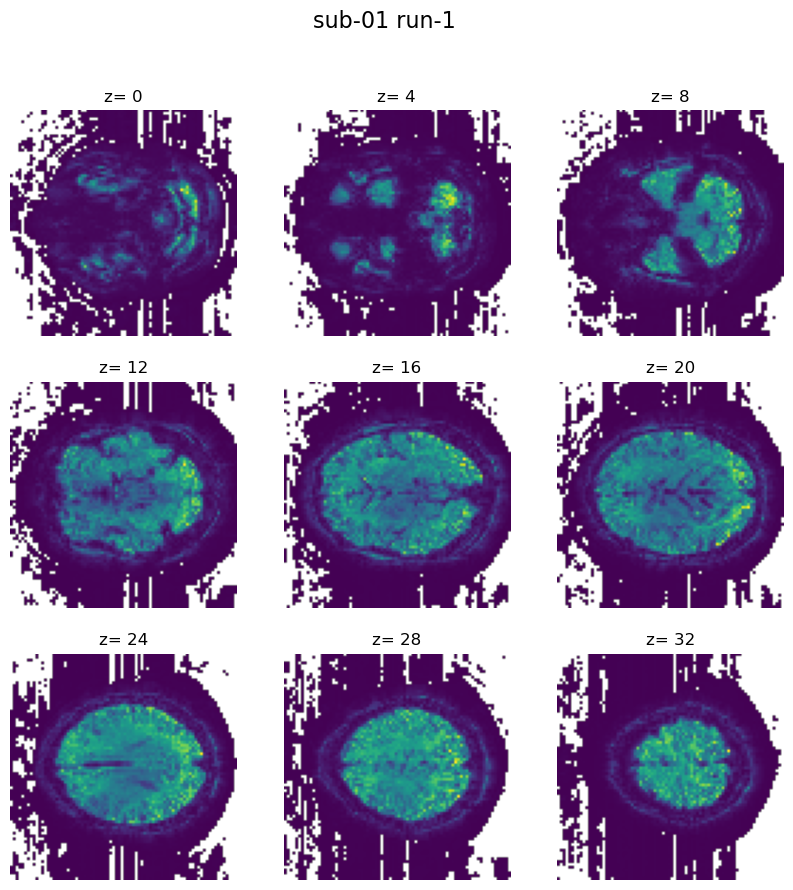

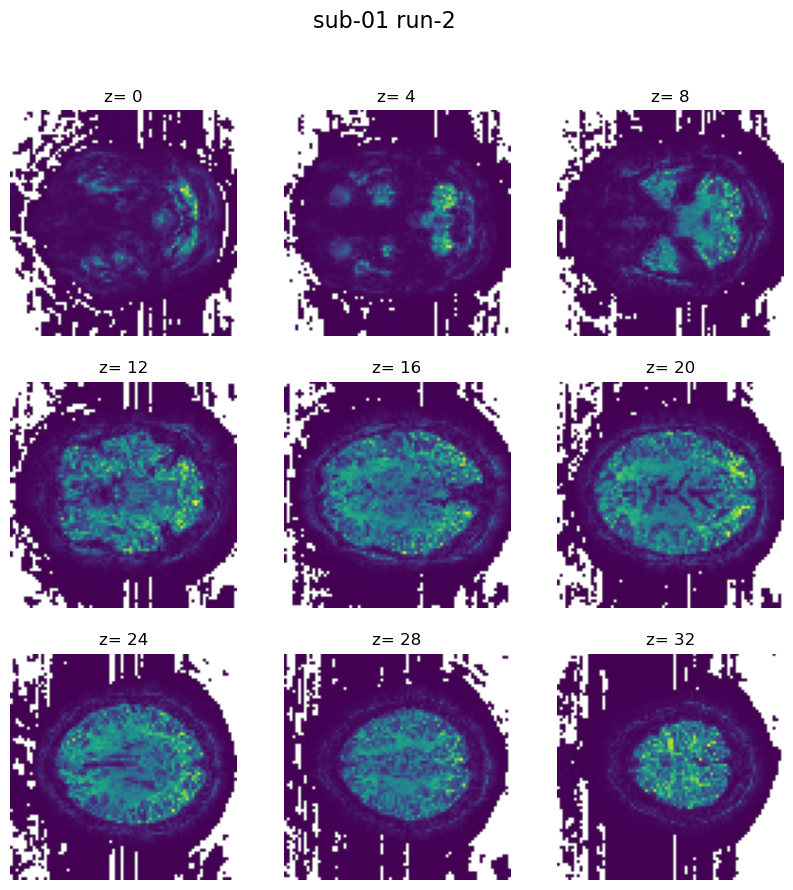

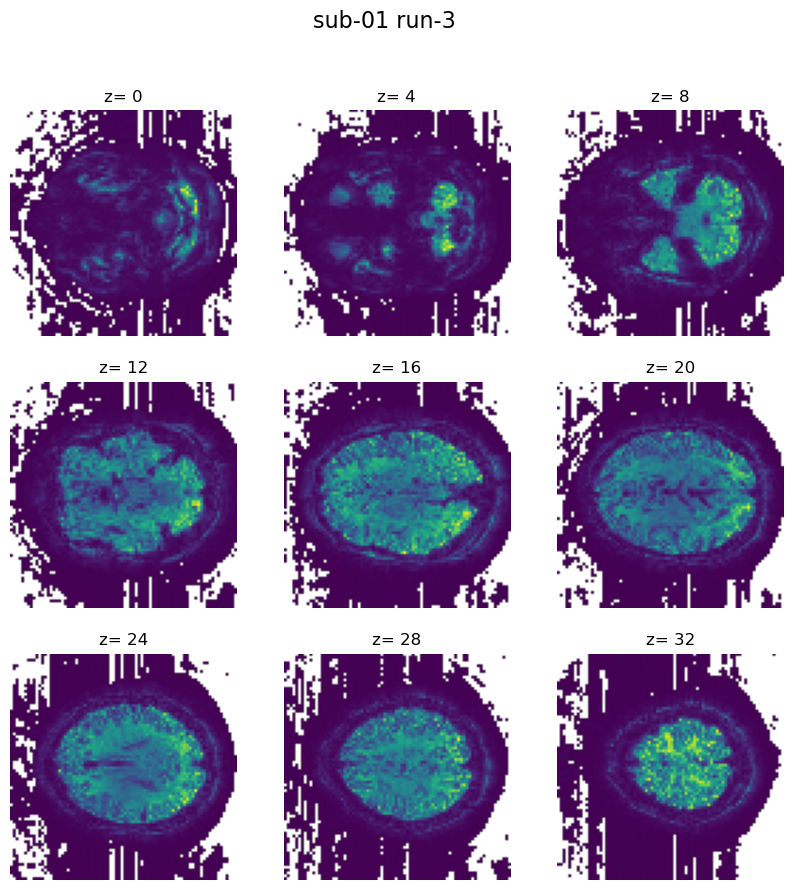

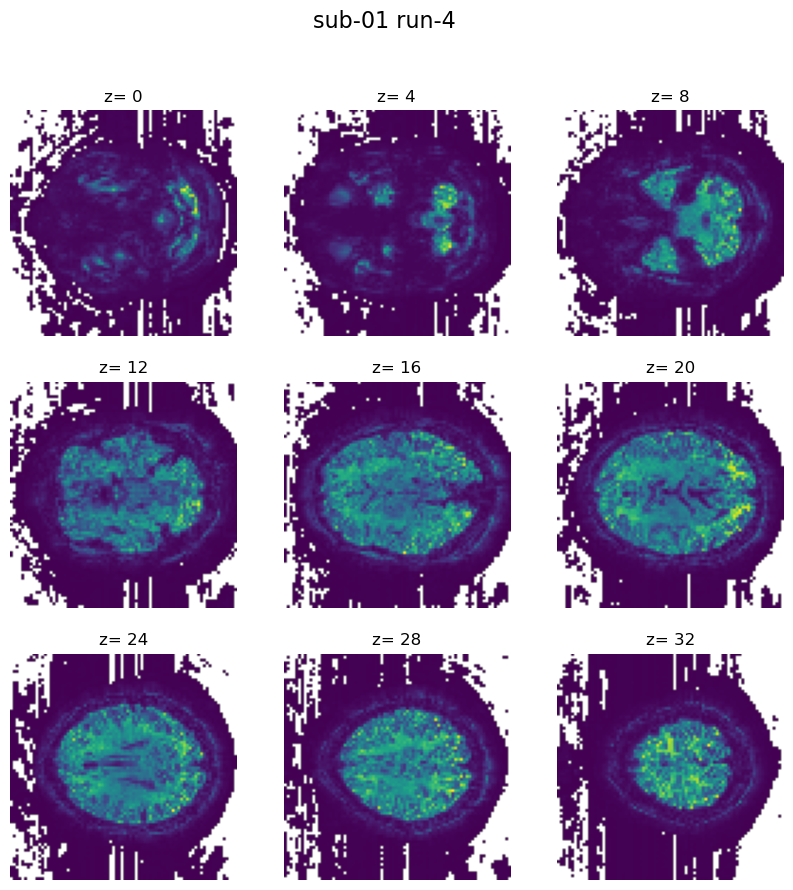

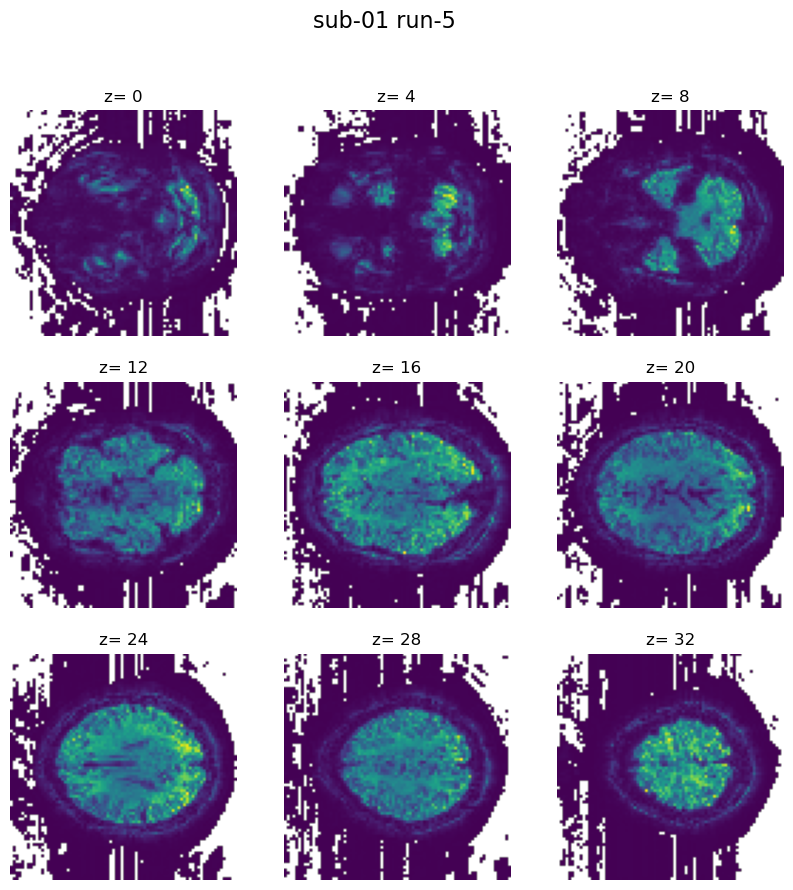

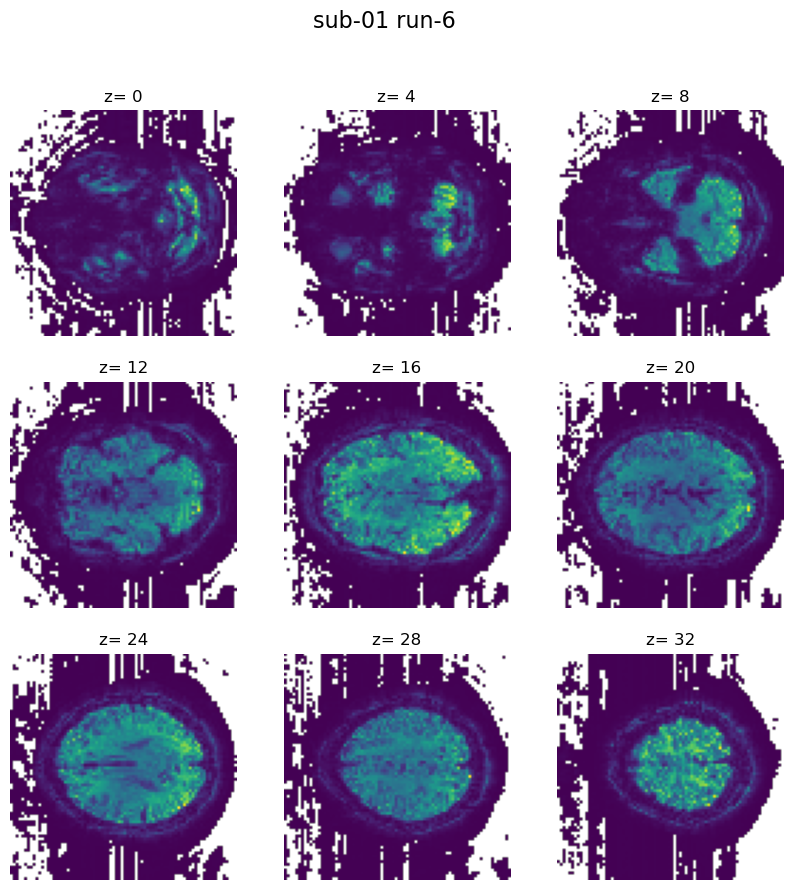

In [ ]:
# Plot SNR maps for all runs
import matplotlib.pyplot as plt

sub = '01'
for run in range(1, 7):
    fn = op.join(bids_folder, f'sub-{sub}','ses-1', 'func', f'sub-{sub}_ses-1_task-chase_run-{run}_bold.nii.gz')
    epi = nib.load(fn)

    ts_3d = epi.get_fdata()
    snr_3d = np.mean(ts_3d, axis=3)/np.std(ts_3d, axis=3)

    fig, axs = plt.subplots(3,3, figsize=(10, 10))
    axs = axs.flatten()
    for i in range(9):
        z_pos = i * 4 # Adjust the step size as needed
        axs[i].imshow(snr_3d[:, :, z_pos], cmap='viridis')
        axs[i].set_title(f'z= {z_pos}')
        axs[i].axis('off')
    fig.suptitle(f'sub-{sub} run-{run}', fontsize=16)
    #plt.savefig(op.join(plots_folder, f'sub-{sub}_run-{run}.png'))

In [13]:
prep_dir_token = "RL"  # `"PrepDirection": "RL"` in json !!!!!

affine = nifti_data.affine

# find which voxel axis (i/j/k -> 0/1/2) mostly maps to the requested world axis
# compute world delta for +1 along each voxel axis
deltas = []
for axis in range(3):
    p0 = np.dot(affine, np.array([0,0,0,1]))[:3]
    p1 = np.dot(affine, np.array([0,0,0,1]))[:3].copy()
    step = np.zeros(3); step[axis] = 1
    p1 = np.dot(affine, np.array([ int(axis==0), int(axis==1), int(axis==2), 1]))[:3]
    deltas.append(p1 - p0)

prep_to_world = {
    "RL": ("x", "R_to_L"),  # Right -> Left
    "LR": ("x", "L_to_R"),
    "AP": ("y", "A_to_P"),
    "PA": ("y", "P_to_A"),
    "SI": ("z", "S_to_I"),
    "IS": ("z", "I_to_S"),
}
world_unit = {"x": np.array([1.0, 0.0, 0.0]), "y": np.array([0.0, 1.0, 0.0]), "z": np.array([0.0, 0.0, 1.0])}

# determine target world axis (x/y/z) and direction meaning (R_to_L etc.)
world_axis, meaning = prep_to_world[prep_dir_token]
u = world_unit[world_axis]

# compute dot of each delta with world unit -> which voxel axis aligns best with world axis
dots = [float(np.dot(delta, u)) for delta in deltas]
voxel_axis = int(np.argmax(np.abs(dots)))   # 0 -> i, 1 -> j, 2 -> k
dot = dots[voxel_axis]

In [14]:
# Now determine sign: dot > 0 means increasing voxel index goes toward positive world axis (e.g. +x = Right)
# Interpret PrepDirection semantics:
# - For "RL": phase encoding goes Right -> Left (i.e. +x -> -x). If increasing voxel index moves toward +x (dot>0),
#   this means the PE direction is opposite to increasing index -> we need '-'
# - For "LR": L->R (i.e. -x -> +x). If increasing index moves toward +x, that's same direction -> no '-'
want_minus = False
if prep_dir_token in ("RL", "PA", "IS"):  # these indicate movement from positive world axis to negative
    # RL: R->L means positive x -> negative x
    # PA: P->A means positive y -> negative y
    # IS: S->I means positive z -> negative z
    # If increasing index moves toward positive world axis (dot > 0), then PE is opposite -> need '-'
    want_minus = dot > 0
else:
    # tokens LR, AP, SI indicate movement from negative world axis to positive world axis
    # If increasing index moves toward positive world axis (dot > 0), then PE is same direction -> no '-'
    want_minus = dot < 0

axis_letter = ["i", "j", "k"][voxel_axis]
if want_minus:
    axis_letter += "-"

axis_letter, voxel_axis, dot

('i', 0, -3.0)

## Fmap json update with "IntendedFor"
Add "IntendedFor"

In [ ]:
import json
from pathlib import Path

bids_sub_root = op.join(bids_folder, f'sub-{sub}', 'ses-1')
acq_to_runs = {
    "2": [1, 2],
    "5": [3, 4],
    "8": [5, 6],}

for acq, runs in acq_to_runs.items():
    phase1_json = op.join(bids_sub_root, 'fmap', f'sub-01_ses-1_acq-{acq}_phase1.json')
    intended_for = [f"ses-1/func/sub-01_ses-1_task-chase_run-{r}_bold.nii.gz" for r in runs]
    with open(phase1_json, "r", encoding="utf-8") as f:
        data = json.load(f)
    data["IntendedFor"] = intended_for
    with open(phase1_json, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)
    print(f"✅ Updated {phase1_json} with IntendedFor = {intended_for}")


✅ Updated /mnt_01/ds-asd_fmaptry/sub-01/ses-1/fmap/sub-01_ses-1_acq-2_phase1.json with IntendedFor = ['ses-1/func/sub-01_ses-1_task-chase_run-1_bold.nii.gz', 'ses-1/func/sub-01_ses-1_task-chase_run-2_bold.nii.gz']
✅ Updated /mnt_01/ds-asd_fmaptry/sub-01/ses-1/fmap/sub-01_ses-1_acq-5_phase1.json with IntendedFor = ['ses-1/func/sub-01_ses-1_task-chase_run-3_bold.nii.gz', 'ses-1/func/sub-01_ses-1_task-chase_run-4_bold.nii.gz']
✅ Updated /mnt_01/ds-asd_fmaptry/sub-01/ses-1/fmap/sub-01_ses-1_acq-8_phase1.json with IntendedFor = ['ses-1/func/sub-01_ses-1_task-chase_run-5_bold.nii.gz', 'ses-1/func/sub-01_ses-1_task-chase_run-6_bold.nii.gz']


In [14]:
import os

sub = '01'
sorted(os.listdir(op.join(bids_folder, f'sub-{sub}','ses-1', 'fmap')))

['sub-01_ses-1_acq-2_magnitude1.nii.gz',
 'sub-01_ses-1_acq-2_magnitude2.nii.gz',
 'sub-01_ses-1_acq-2_phase1.json',
 'sub-01_ses-1_acq-2_phase1.nii.gz',
 'sub-01_ses-1_acq-2_phase1.par',
 'sub-01_ses-1_acq-2_phase2.json',
 'sub-01_ses-1_acq-2_phase2.nii.gz',
 'sub-01_ses-1_acq-2_recording-scanphys_physio.json',
 'sub-01_ses-1_acq-2_recording-scanphys_physio.log',
 'sub-01_ses-1_acq-2_recording-scanphys_physio.tsv.gz',
 'sub-01_ses-1_acq-5_magnitude1.nii.gz',
 'sub-01_ses-1_acq-5_magnitude2.nii.gz',
 'sub-01_ses-1_acq-5_phase1.json',
 'sub-01_ses-1_acq-5_phase1.nii.gz',
 'sub-01_ses-1_acq-5_phase1.par',
 'sub-01_ses-1_acq-5_phase2.json',
 'sub-01_ses-1_acq-5_phase2.nii.gz',
 'sub-01_ses-1_acq-5_recording-scanphys_physio.json',
 'sub-01_ses-1_acq-5_recording-scanphys_physio.log',
 'sub-01_ses-1_acq-5_recording-scanphys_physio.tsv.gz',
 'sub-01_ses-1_acq-8_magnitude1.nii.gz',
 'sub-01_ses-1_acq-8_magnitude2.nii.gz',
 'sub-01_ses-1_acq-8_phase1.json',
 'sub-01_ses-1_acq-8_phase1.nii.gz',


In [10]:
sorted(os.listdir(op.join(bids_folder, f'sub-{sub}','ses-1', 'func')))


['sub-01_ses-1_task-chase_run-1_bold.json',
 'sub-01_ses-1_task-chase_run-1_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-2_bold.json',
 'sub-01_ses-1_task-chase_run-2_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-3_bold.json',
 'sub-01_ses-1_task-chase_run-3_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-4_bold.json',
 'sub-01_ses-1_task-chase_run-4_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-5_bold.json',
 'sub-01_ses-1_task-chase_run-5_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-6_bold.json',
 'sub-01_ses-1_task-chase_run-6_bold.nii.gz']

In [9]:
sorted(os.listdir(op.join(bids_folder, f'sub-{sub}','ses-1', 'func')))



['sub-01_ses-1_task-chase_run-1_bold.json',
 'sub-01_ses-1_task-chase_run-1_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-2_bold.json',
 'sub-01_ses-1_task-chase_run-2_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-3_bold.json',
 'sub-01_ses-1_task-chase_run-3_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-4_bold.json',
 'sub-01_ses-1_task-chase_run-4_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-5_bold.json',
 'sub-01_ses-1_task-chase_run-5_bold.nii.gz',
 'sub-01_ses-1_task-chase_run-6_bold.json',
 'sub-01_ses-1_task-chase_run-6_bold.nii.gz']

old BIDS folders

/mnt_01/ds-asd_old-BIDS/sub-00001/ses-00001/fmap/

In [ ]:
import json

json_file = op.join(bids_folder, f'sub-{sub}', 'ses-1', 'fmap', f'sub-{sub}_ses-1_dir-AP_epi.json')

In [ ]:
import json

# Load the JSON file
with open('your_file.json', 'r') as f:
    data = json.load(f)

# Replace a value
if data.get("TaskName") == "fmri":
    data["TaskName"] = "chase"  # or whatever new value you want

# Optionally add a new key
data["task"] = "chase"

# Save the changes back to the file
with open('your_file.json', 'w') as f:
    json.dump(data, f, indent=4)